In [1]:
import pandas as pd
import numpy as np
import pickle, json

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    use_xgb = True
except ImportError:
    use_xgb = False

import warnings
warnings.filterwarnings('ignore')

OUTPUT_PATH = "../data/raw/"

Load Data

In [2]:
base_path = '../data/raw/'

df_match    = pd.read_csv(base_path + 'gold_match.csv')
df_trends   = pd.read_csv(base_path + 'gold_google_trends_daily.csv')
df_tickets  = pd.read_csv(base_path + 'gold_match_tickets.csv')
df_context  = pd.read_csv(base_path + 'gold_match_context.csv')
df_goals    = pd.read_csv(base_path + 'gold_match_goals.csv')
df_articles = pd.read_csv(base_path + 'gold_belga_press_articles.csv',
                           escapechar='\\', on_bad_lines='skip')

data = df_match.merge(df_context, on='match_id', how='left')
data = data.merge(df_tickets, on='match_id', how='left')
data = data.dropna(subset=['tickets_scanned'])

print("Merged view shape:", data.shape)
data.head()

Merged view shape: (80, 70)


,match_id,match_date_x,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,campaign_motto,tickets_sold_b2c,tickets_sold_b2b,tickets_sold_total,seasonpass_holders,tickets_trib1,tickets_trib2_thuis,tickets_trib2_uit,tickets_trib3,tickets_trib4
1,d256yo3eng04m0fu7b4sl7wno,2022-07-30,18:15:00,2022-07-30Z,16:15:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,488.0,764.0,5025.0,4032.0,1899.0,127.0,0.0,1427.0,1572.0
3,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18:30:00,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,1448.0,1284.0,6263.0,4032.0,2387.0,323.0,0.0,1982.0,1571.0
5,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18:15:00,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,439.0,823.0,5025.0,4032.0,1876.0,126.0,0.0,1453.0,1570.0
7,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20:45:00,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,782.0,906.0,5438.0,4032.0,1897.0,560.0,0.0,1411.0,1570.0
9,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,16:00:00,2022-10-01Z,14:00:00Z,10.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,NaN,1115.0,970.0,5844.0,4032.0,2163.0,355.0,0.0,1757.0,1569.0


DATA PREP

In [3]:
df = df_match[df_match['is_home_match'] == True].copy()
df = df.merge(df_tickets, on='match_id', how='left')
df = df.merge(df_context, on='match_id', how='left')
df['match_date'] = df['match_date_x']
df = df.drop(columns=['match_date_x', 'match_date_y'], errors='ignore')

# Google Trends — 7-day average pre-match
df_trends_agg = df_trends.groupby('match_id')['ohl_interest'].mean().reset_index()
df = df.merge(df_trends_agg, on='match_id', how='left')

# Total article count (all linked articles)
df_articles_agg = df_articles.groupby('match_id').size().reset_index(name='article_count')
df = df.merge(df_articles_agg, on='match_id', how='left')
df['article_count'] = df['article_count'].fillna(0)

# Pre-match article count (7 days before matchday only — no leakage)
df_articles['date'] = pd.to_datetime(df_articles['date'])

art_pre = []
for _, row in df[['match_id', 'match_date']].iterrows():
    window = df_articles[
        (df_articles['match_id'] == row['match_id']) &
        (df_articles['days_to_match'].between(-7, -1))
    ]
    art_pre.append({'match_id': row['match_id'], 'article_count_7d': len(window)})

df_art_pre = pd.DataFrame(art_pre)
df = df.merge(df_art_pre, on='match_id', how='left')
df['article_count_7d'] = df['article_count_7d'].fillna(0)

df = df.sort_values('match_date').reset_index(drop=True)
print("Data prep complete:", df.shape)

Data prep complete: (71, 72)


Feature Engineering (Combined)


In [4]:
df['kickoff_hour'] = pd.to_datetime(
    df['kickoff_time_local'], format='%H:%M:%S'
).dt.hour

points_map = {'W': 3, 'D': 1, 'L': 0}
df['points'] = df['result_home'].map(points_map)
df['points_last_5'] = df['points'].rolling(5).sum().shift(1).fillna(df['points'].mean() * 5)
df['win'] = (df['result_home'] == 'W').astype(int)
df['wins_last_3'] = df['win'].rolling(3).sum().shift(1).fillna(df['win'].mean() * 3)
df['goal_diff'] = df['goals_home_ft'] - df['goals_away_ft']
df['goal_diff_last_5'] = df['goal_diff'].rolling(5).sum().shift(1).fillna(0)

df['matchday'] = pd.to_numeric(df['matchday'], errors='coerce')
df['season_progress'] = df['matchday'] / df['matchday'].max()

df['form_strength_norm'] = (
    (df['points_last_5'] - df['points_last_5'].min()) /
    (df['points_last_5'].max() - df['points_last_5'].min())
)
df['match_importance'] = 0.5 * df['form_strength_norm'] + 0.5 * df['season_progress']
df['is_high_importance'] = (df['match_importance'] > df['match_importance'].median()).astype(int)

df['opponent'] = df['away_team']
df['opponent_freq'] = df['opponent'].map(df['opponent'].value_counts())

top_teams = ["Club Brugge", "Anderlecht", "STVV", "KV Mechelen", "Westerlo"]
df['is_top_opponent'] = df['away_team'].isin(top_teams).astype(int)

df['opponent_strength_norm'] = (
    (df['opponent_freq'] - df['opponent_freq'].min()) /
    (df['opponent_freq'].max() - df['opponent_freq'].min())
)

df['match_attractiveness'] = (
    0.4 * df['match_importance'] +
    0.4 * df['opponent_strength_norm'] +
    0.2 * df['is_top_opponent']
)
df['form_x_opponent'] = df['points_last_5'] * df['is_top_opponent']

df['opponent_avg_attendance_raw'] = df.groupby('away_team')['tickets_sold_total'].transform('mean')

df['attendance_lag_1'] = df['tickets_scanned'].shift(1).fillna(df['tickets_scanned'].mean())
df['has_promotion'] = df['has_promotion'].astype(int)

df['is_school_holiday_flanders'] = df['is_school_holiday_flanders'].astype(int)
df['is_public_holiday']          = df['is_public_holiday'].astype(int)
df['is_midweek']                 = df['is_midweek'].astype(int)

df['is_playoff'] = df['stage'].str.contains('Playoff|Play-off', case=False, na=False).astype(int)

result_map = {'W': 1, 'D': 0, 'L': -1}
df['last_result_vs_opponent_enc'] = df['last_result_vs_opponent'].map(result_map).fillna(0)

df['ohl_interest']    = df['ohl_interest'].fillna(df['ohl_interest'].median())
df['weather_score']   = df['weather_score'].fillna(df['weather_score'].median())
df['weather_rain_mm'] = df['weather_rain_mm'].fillna(df['weather_rain_mm'].median())

df['promo_x_top_opponent'] = df['has_promotion'] * df['is_top_opponent']
df['lag_x_form']           = df['attendance_lag_1'] * df['points_last_5']
df['rain_x_weekend']       = df['weather_rain_mm'] * df['is_weekend']
df['playoff_x_top']        = df['is_playoff'] * df['is_top_opponent']

df['attendance_roll_3'] = df['tickets_scanned'].rolling(3).mean().shift(1).fillna(df['tickets_scanned'].mean())
df['attendance_roll_5'] = df['tickets_scanned'].rolling(5).mean().shift(1).fillna(df['tickets_scanned'].mean())

df['season_enc'] = pd.factorize(df['season'])[0]

print("Feature engineering complete:", df.shape)

Feature engineering complete: (71, 100)


Sigmoid Normalization (Optional)


In [5]:
STADIUM_CAPACITY = 10_000
USE_SIGMOID_TARGET = False
USE_LOG_TARGET     = True   # log transform reduces skewness and helps at extremes

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def normalize_attendance(y, capacity=STADIUM_CAPACITY):
    rate = y / capacity
    centered = rate - 0.5
    return sigmoid(centered * 6)

def inverse_sigmoid_attendance(y_sig, capacity=STADIUM_CAPACITY):
    clipped = np.clip(y_sig, 1e-6, 1 - 1e-6)
    centered = np.log(clipped / (1 - clipped)) / 6
    return (centered + 0.5) * capacity

Features set

In [6]:
features_combined = [
    'attendance_lag_1',
    'attendance_roll_3',
    'attendance_roll_5',
    'tickets_sold_b2c',
    'tickets_sold_b2b',
    'seasonpass_holders',
    'opponent_avg_attendance_raw',
    'is_top_opponent',
    'last_result_vs_opponent_enc',
    'points_last_5',
    'goal_diff_last_5',
    'form_x_opponent',
    'match_importance',
    'match_attractiveness',
    'season_progress',
    'season_enc',
    'is_playoff',
    'has_promotion',
    'pct_free_tickets',
    'is_weekend',
    'is_midweek',
    'kickoff_hour',
    'is_school_holiday_flanders',
    'is_public_holiday',
    'academic_week',
    'weather_score',
    'weather_rain_mm',
    'ohl_interest',
    'article_count_7d',
    'promo_x_top_opponent',
    'lag_x_form',
    'rain_x_weekend',
    'playoff_x_top',
]

features_combined = [col for col in features_combined if col in df.columns]

target   = 'tickets_scanned'
df_model = df[features_combined + [target, 'away_team']].dropna()
X        = df_model[features_combined]
y        = df_model[target]

if USE_LOG_TARGET:
    y_fit = np.log(y)
elif USE_SIGMOID_TARGET:
    y_fit = normalize_attendance(y)
else:
    y_fit = y

print(f"Dataset: {df_model.shape[0]} rows, {len(features_combined)} features")
print(f"Features: {features_combined}")

Dataset: 71 rows, 33 features
Features: ['attendance_lag_1', 'attendance_roll_3', 'attendance_roll_5', 'tickets_sold_b2c', 'tickets_sold_b2b', 'seasonpass_holders', 'opponent_avg_attendance_raw', 'is_top_opponent', 'last_result_vs_opponent_enc', 'points_last_5', 'goal_diff_last_5', 'form_x_opponent', 'match_importance', 'match_attractiveness', 'season_progress', 'season_enc', 'is_playoff', 'has_promotion', 'pct_free_tickets', 'is_weekend', 'is_midweek', 'kickoff_hour', 'is_school_holiday_flanders', 'is_public_holiday', 'academic_week', 'weather_score', 'weather_rain_mm', 'ohl_interest', 'article_count_7d', 'promo_x_top_opponent', 'lag_x_form', 'rain_x_weekend', 'playoff_x_top']


Feature Importance Ranking

In [7]:
scaler_fi   = StandardScaler()
X_scaled_fi = scaler_fi.fit_transform(X)

rf_fi = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
gb_fi = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
rr_fi = Ridge(alpha=10)

rf_fi.fit(X_scaled_fi, y_fit)
gb_fi.fit(X_scaled_fi, y_fit)
rr_fi.fit(X_scaled_fi, y_fit)

fi_rf   = pd.Series(rf_fi.feature_importances_, index=features_combined, name="RandomForest")
fi_gb   = pd.Series(gb_fi.feature_importances_, index=features_combined, name="GradientBoosting")
fi_rr   = pd.Series(np.abs(rr_fi.coef_),        index=features_combined, name="Ridge_abs_coef")

perm    = permutation_importance(rf_fi, X_scaled_fi, y_fit, n_repeats=30, random_state=42)
fi_perm = pd.Series(perm.importances_mean,       index=features_combined, name="Permutation")

fi_df      = pd.concat([fi_rf, fi_gb, fi_rr, fi_perm], axis=1)
fi_df_norm = fi_df.apply(lambda col: (col - col.min()) / (col.max() - col.min()))
fi_df_norm["mean_score"] = fi_df_norm.mean(axis=1)
fi_df_norm = fi_df_norm.sort_values("mean_score", ascending=False)

print("── Feature Importance Ranking (normalised 0–1) ──────────────")
print(fi_df_norm.round(3).to_string())

── Feature Importance Ranking (normalised 0–1) ──────────────
                             RandomForest  GradientBoosting  Ridge_abs_coef  Permutation  mean_score
attendance_lag_1                    0.987             1.000           0.577        1.000       0.891
attendance_roll_3                   1.000             0.525           0.375        0.964       0.716
tickets_sold_b2c                    0.474             0.154           1.000        0.546       0.543
tickets_sold_b2b                    0.520             0.436           0.308        0.621       0.471
opponent_avg_attendance_raw         0.385             0.506           0.389        0.348       0.407
pct_free_tickets                    0.209             0.127           0.529        0.267       0.283
match_attractiveness                0.235             0.193           0.405        0.194       0.257
goal_diff_last_5                    0.190             0.155           0.373        0.154       0.218
season_enc                   

RFECV Feature Selection

In [8]:
PROTECTED = [
    'attendance_lag_1',
    'attendance_roll_3',
    'tickets_sold_b2c',
    'tickets_sold_b2b',
    'opponent_avg_attendance_raw',
    'weather_rain_mm',
    'has_promotion',
    'points_last_5',
    'is_top_opponent',
]

rfe = RFECV(
    estimator=Ridge(alpha=100),
    step=1,
    cv=LeaveOneOut(),
    scoring='neg_mean_absolute_error',
    min_features_to_select=3
)

unprotected = [f for f in features_combined if f not in PROTECTED]
rfe.fit(StandardScaler().fit_transform(df_model[unprotected]), y)

rfecv_selected  = [f for f, s in zip(unprotected, rfe.support_) if s]
eliminated      = [f for f, s in zip(unprotected, rfe.support_) if not s]
selected_features = [f for f in features_combined if f in rfecv_selected + PROTECTED]

print(f" Protected:            {PROTECTED}")
print(f" RFECV selected ({len(rfecv_selected)}): {rfecv_selected}")
print(f" Eliminated ({len(eliminated)}):    {eliminated}")
print(f"\n Final feature set ({len(selected_features)}):")
for f in selected_features:
    print(f"   + {f}")

mae_per_n = -rfe.cv_results_['mean_test_score']
n_range   = range(rfe.min_features_to_select, len(unprotected) + 1)
print(f"\n── MAE by feature count (excl. protected) ───────────────────")
for n, mae in zip(n_range, mae_per_n):
    marker = " ← optimal" if n == rfe.n_features_ else ""
    print(f"  n={n:>2}  MAE: {mae:>8.1f}{marker}")

 Protected:            ['attendance_lag_1', 'attendance_roll_3', 'tickets_sold_b2c', 'tickets_sold_b2b', 'opponent_avg_attendance_raw', 'weather_rain_mm', 'has_promotion', 'points_last_5', 'is_top_opponent']
 RFECV selected (12): ['attendance_roll_5', 'goal_diff_last_5', 'form_x_opponent', 'match_attractiveness', 'season_progress', 'season_enc', 'is_playoff', 'pct_free_tickets', 'kickoff_hour', 'ohl_interest', 'article_count_7d', 'lag_x_form']
 Eliminated (12):    ['seasonpass_holders', 'last_result_vs_opponent_enc', 'match_importance', 'is_weekend', 'is_midweek', 'is_school_holiday_flanders', 'is_public_holiday', 'academic_week', 'weather_score', 'promo_x_top_opponent', 'rain_x_weekend', 'playoff_x_top']

 Final feature set (21):
   + attendance_lag_1
   + attendance_roll_3
   + attendance_roll_5
   + tickets_sold_b2c
   + tickets_sold_b2b
   + opponent_avg_attendance_raw
   + is_top_opponent
   + points_last_5
   + goal_diff_last_5
   + form_x_opponent
   + match_attractiveness
   + 

Apply Selected Features


In [9]:
# Final 21 features selected by RFECV
features_combined = [
    'attendance_lag_1',
    'attendance_roll_3',
    'attendance_roll_5',
    'tickets_sold_b2c',
    'tickets_sold_b2b',
    'opponent_avg_attendance_raw',
    'is_top_opponent',
    'points_last_5',
    'goal_diff_last_5',
    'form_x_opponent',
    'match_attractiveness',
    'season_progress',
    'season_enc',
    'is_playoff',
    'has_promotion',
    'pct_free_tickets',
    'kickoff_hour',
    'weather_rain_mm',
    'ohl_interest',
    'article_count_7d',
    'lag_x_form',
]

features_combined = [col for col in features_combined if col in df.columns]

target   = 'tickets_scanned'
df_model = df[features_combined + [target, 'away_team']].dropna()
X        = df_model[features_combined]
y        = df_model[target]

if USE_LOG_TARGET:
    y_fit = np.log(y)
elif USE_SIGMOID_TARGET:
    y_fit = normalize_attendance(y)
else:
    y_fit = y

print(f"Dataset: {df_model.shape[0]} rows, {len(features_combined)} features")

Dataset: 71 rows, 21 features


Hyperparameter Tuning

In [10]:
model = GradientBoostingRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    subsample=0.7, min_samples_leaf=8, random_state=42
)

print('Model initialised.')

Model initialised.


Model Training + LOOCV

In [11]:
loo = LeaveOneOut()
y_true_list, y_pred_list = [], []

LOG_CLIP_MIN, LOG_CLIP_MAX = 6.0, 10.5

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold    = y_fit.iloc[train_idx]

    if 'opponent_avg_attendance_raw' in features_combined:
        opp_avg         = df_model.iloc[train_idx].groupby('away_team')[target].mean()
        global_avg_fold = y.iloc[train_idx].mean()
        opp_test        = df_model.iloc[test_idx]['away_team'].values[0]
        X_train = X_train.copy(); X_test = X_test.copy()
        X_train['opponent_avg_attendance_raw'] = df_model.iloc[train_idx]['away_team'].map(opp_avg)
        X_test['opponent_avg_attendance_raw']  = opp_avg.get(opp_test, global_avg_fold)

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_train)
    X_te_s  = scaler.transform(X_test)

    model.fit(X_tr_s, y_train_fold)
    pred = model.predict(X_te_s)[0]

    if USE_LOG_TARGET:
        pred = np.exp(np.clip(pred, LOG_CLIP_MIN, LOG_CLIP_MAX))
    elif USE_SIGMOID_TARGET:
        pred = inverse_sigmoid_attendance(pred)

    y_true_list.append(y.iloc[test_idx].values[0])
    y_pred_list.append(pred)

results_df = pd.DataFrame({
    "MAE":  [mean_absolute_error(y_true_list, y_pred_list)],
    "RMSE": [np.sqrt(mean_squared_error(y_true_list, y_pred_list))],
    "R2":   [r2_score(y_true_list, y_pred_list)],
    "MAPE": [np.mean(np.abs((np.array(y_true_list) - np.array(y_pred_list)) / np.array(y_true_list))) * 100]
}, index=["GradientBoosting"])

predictions_dict = {"GradientBoosting": pd.DataFrame({"Actual": y_true_list, "Predicted": y_pred_list})}

print(results_df.round(2))

                     MAE     RMSE    R2   MAPE
GradientBoosting  875.49  1144.74  0.67  13.89


Overfit Check

In [12]:
scaler_full = StandardScaler()
X_full_s    = scaler_full.fit_transform(X)
model.fit(X_full_s, y_fit)
y_train_pred = model.predict(X_full_s)

if USE_LOG_TARGET:
    y_train_pred = np.exp(np.clip(y_train_pred, LOG_CLIP_MIN, LOG_CLIP_MAX))
elif USE_SIGMOID_TARGET:
    y_train_pred = inverse_sigmoid_attendance(y_train_pred)

train_mae = mean_absolute_error(y, y_train_pred)
train_r2  = r2_score(y, y_train_pred)
loocv_mae = results_df.loc["GradientBoosting", "MAE"]
loocv_r2  = results_df.loc["GradientBoosting", "R2"]

print('── Overfit Check (LOOCV vs Full-Train) ──────────────────────')
print(f'  Train MAE : {train_mae:.1f}   LOOCV MAE : {loocv_mae:.1f}   gap: {loocv_mae - train_mae:.1f}')
print(f'  Train R²  : {train_r2:.3f}   LOOCV R²  : {loocv_r2:.3f}   gap: {loocv_r2 - train_r2:.3f}')
print()
print('  Boosting fits training data tightly by design.')
print('  LOOCV is the honest metric — every prediction was out-of-sample.')
print(f'{"─"*54}')
print(f'  LOOCV MAE : {loocv_mae:.0f} spectators')
print(f'  LOOCV R²  : {loocv_r2:.3f}')
print(f'{"─"*54}')

── Overfit Check (LOOCV vs Full-Train) ──────────────────────
  Train MAE : 240.4   LOOCV MAE : 875.5   gap: 635.1
  Train R²  : 0.971   LOOCV R²  : 0.666   gap: -0.305

  Boosting fits training data tightly by design.
  LOOCV is the honest metric — every prediction was out-of-sample.
──────────────────────────────────────────────────────
  LOOCV MAE : 875 spectators
  LOOCV R²  : 0.666
──────────────────────────────────────────────────────


## Error Analysis

Best model : GradientBoosting
MAE        : 875 spectators
Median error: 648 spectators
Within ±500 : 27/71 (38%)
Within ±1000: 48/71 (68%)
Over  ±2000 : 6/71 (8%)
Worst miss  : 3455 spectators

── Top 5 best predictions ───────────────────────────────
 actual  predicted     error
 7440.0     7431.0  9.166286
 6360.0     6309.0 50.866346
 5907.0     5967.0 60.374409
10786.0    10855.0 68.871746
 5782.0     5862.0 80.479872

── Top 5 worst predictions ──────────────────────────────
 actual  predicted       error
 9331.0     6905.0 2426.331858
 3766.0     6246.0 2480.495206
 7785.0     5279.0 2506.359650
 3537.0     6331.0 2794.288944
10723.0     7268.0 3454.558247


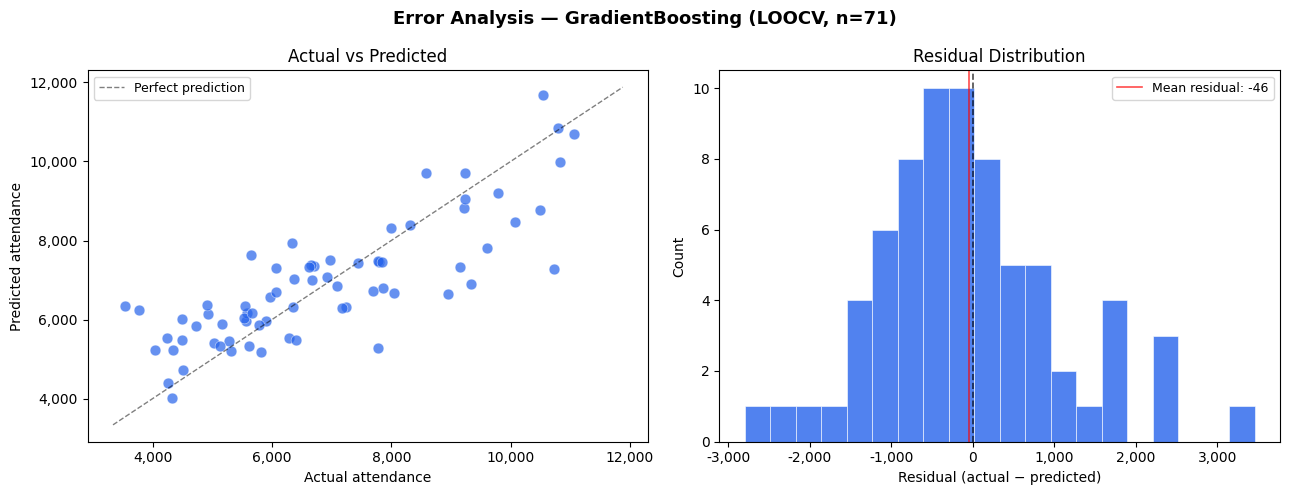

Saved: error_analysis.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

best_name = results_df.index[0]
y_true_arr = np.array(predictions_dict[best_name]['Actual'])
y_pred_arr = np.array(predictions_dict[best_name]['Predicted'])
errors     = np.abs(y_true_arr - y_pred_arr)
residuals  = y_true_arr - y_pred_arr

pred_df = pd.DataFrame({
    'actual':    y_true_arr,
    'predicted': y_pred_arr.round(),
    'error':     errors,
    'residual':  residuals,
}).sort_values('error').reset_index(drop=True)

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"Best model : {best_name}")
print(f"MAE        : {errors.mean():.0f} spectators")
print(f"Median error: {np.median(errors):.0f} spectators")
print(f"Within ±500 : {(errors <= 500).sum()}/{len(errors)} ({(errors <= 500).mean()*100:.0f}%)")
print(f"Within ±1000: {(errors <= 1000).sum()}/{len(errors)} ({(errors <= 1000).mean()*100:.0f}%)")
print(f"Over  ±2000 : {(errors > 2000).sum()}/{len(errors)} ({(errors > 2000).mean()*100:.0f}%)")
print(f"Worst miss  : {errors.max():.0f} spectators\n")

print("── Top 5 best predictions ───────────────────────────────")
print(pred_df.head(5)[['actual', 'predicted', 'error']].to_string(index=False))

print("\n── Top 5 worst predictions ──────────────────────────────")
print(pred_df.tail(5)[['actual', 'predicted', 'error']].to_string(index=False))

# ── Residual plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Error Analysis — {best_name} (LOOCV, n=71)", fontsize=13, fontweight='bold')

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_true_arr, y_pred_arr, alpha=0.7, edgecolors='white', linewidth=0.4,
            color='#2563EB', s=60)
lims = [min(y_true_arr.min(), y_pred_arr.min()) - 200,
        max(y_true_arr.max(), y_pred_arr.max()) + 200]
ax1.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='Perfect prediction')
ax1.set_xlabel('Actual attendance')
ax1.set_ylabel('Predicted attendance')
ax1.set_title('Actual vs Predicted')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))


# Residual distribution
ax2 = axes[1]
ax2.hist(residuals, bins=20, color='#2563EB', alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.axvline(residuals.mean(), color='red', linewidth=1.2, linestyle='-', alpha=0.7,
            label=f'Mean residual: {residuals.mean():.0f}')
ax2.set_xlabel('Residual (actual − predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/raw/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: error_analysis.png")

## Feature Importance

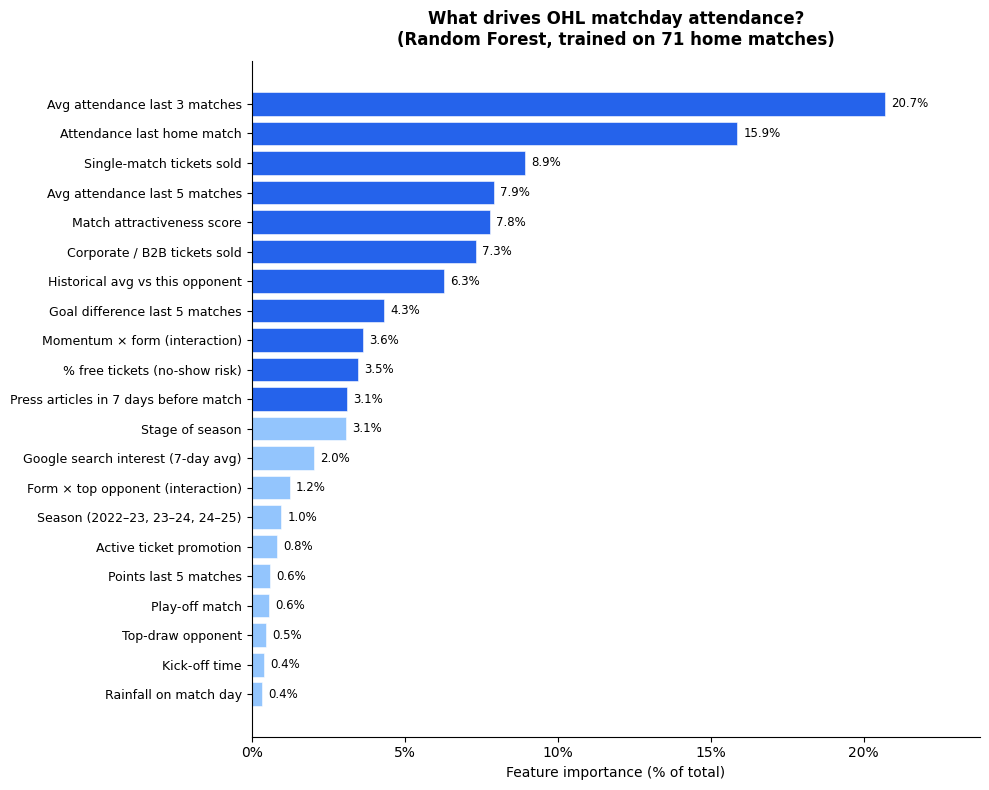

Saved: feature_importance.png


In [14]:
feature_labels = {
    'attendance_lag_1':            'Attendance last home match',
    'attendance_roll_3':           'Avg attendance last 3 matches',
    'attendance_roll_5':           'Avg attendance last 5 matches',
    'tickets_sold_b2c':            'Single-match tickets sold',
    'tickets_sold_b2b':            'Corporate / B2B tickets sold',
    'opponent_avg_attendance_raw': 'Historical avg vs this opponent',
    'is_top_opponent':             'Top-draw opponent',
    'points_last_5':               'Points last 5 matches',
    'goal_diff_last_5':            'Goal difference last 5 matches',
    'form_x_opponent':             'Form × top opponent (interaction)',
    'match_attractiveness':        'Match attractiveness score',
    'season_progress':             'Stage of season',
    'season_enc':                  'Season (2022–23, 23–24, 24–25)',
    'is_playoff':                  'Play-off match',
    'has_promotion':               'Active ticket promotion',
    'pct_free_tickets':            '% free tickets (no-show risk)',
    'kickoff_hour':                'Kick-off time',
    'weather_rain_mm':             'Rainfall on match day',
    'ohl_interest':                'Google search interest (7-day avg)',
    'article_count_7d':            'Press articles in 7 days before match',
    'lag_x_form':                  'Momentum × form (interaction)',
}

scaler_imp = StandardScaler()
rf_imp = RandomForestRegressor(n_estimators=300, max_depth=4, max_features=0.5,
                                min_samples_leaf=3, random_state=42)
rf_imp.fit(scaler_imp.fit_transform(X), y)

fi = (pd.Series(rf_imp.feature_importances_, index=features_combined)
        .rename(index=feature_labels)
        .sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#93C5FD' if v < fi.median() else '#2563EB' for v in fi.values]
bars = ax.barh(fi.index, fi.values, color=colors, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, fi.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=8.5)

ax.set_xlabel('Feature importance (% of total)', fontsize=10)
ax.set_title('What drives OHL matchday attendance?\n(Random Forest, trained on 71 home matches)',
             fontsize=12, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, fi.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('../data/raw/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

SAVE BEST MODEL


In [15]:
scaler_final   = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)
model.fit(X_scaled_final, y_fit)

model_save_path  = '../notebooks/interactive_interface/model.pkl'
lookup_save_path = '../notebooks/interactive_interface/opponent_lookup.json'

with open(model_save_path, 'wb') as f:
    pickle.dump({
        'model':     model,
        'scaler':    scaler_final,
        'features':  features_combined,
        'log_target': USE_LOG_TARGET,
        'sigmoid':   USE_SIGMOID_TARGET,
        'capacity':  STADIUM_CAPACITY,
        'log_clip':  (LOG_CLIP_MIN, LOG_CLIP_MAX),
    }, f)

opp_lookup = df_model.groupby('away_team')[target].mean().round(0).to_dict()
opp_lookup['__global_avg__'] = float(y.mean())
with open(lookup_save_path, 'w') as f:
    json.dump(opp_lookup, f, indent=2)

results_df.to_csv('../data/raw/model_results_combined.csv')
print('GradientBoosting')
print(f'model.pkl, opponent_lookup.json, model_results_combined.csv saved.')

GradientBoosting
model.pkl, opponent_lookup.json, model_results_combined.csv saved.
